# Kunci Jawaban - Linear Regression

- **Dataset:** Real Estate Valuation
- **Target:** `Y house price of unit area`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [ ]:
%pip install ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, scatter plot, dan line plot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE dan regression plot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Real Estate Valuation menggunakan ID dataset dari UCI.

In [5]:
real_estate = fetch_ucirepo(id=477)

### Ambil fitur dari dataset

Simpan fitur dataset ke variabel `X_raw`.

In [6]:
X_raw = real_estate.data.features.copy()

### Ambil target dari dataset

Simpan target dataset ke variabel `y_raw`.

In [7]:
y_raw = real_estate.data.targets.copy()

### Tentukan kolom target

Simpan nama kolom target ke variabel `TARGET_COL` agar mudah dipakai ulang di bagian berikutnya.

In [8]:
TARGET_COL = "Y house price of unit area"

### Tentukan kolom yang tidak digunakan

Simpan kolom date-like yang tidak dipakai untuk modeling sederhana.

In [9]:
DROP_COLS = ["X1 transaction date"]

### Gabungkan fitur dan target

Gabungkan fitur dan target menjadi satu DataFrame bernama `df` agar mudah dicek di tahap EDA.

In [10]:
df = pd.concat([X_raw, y_raw], axis=1)

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom dataset.

In [11]:
df.shape

(414, 7)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki **414 baris** dan **7 kolom**.

> Berapa jumlah fitur dan targetnya?

Jawaban: Dataset awal memiliki **6 fitur** dan **1 target**, yaitu `Y house price of unit area`.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat bentuk data.

In [12]:
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.000,84.879,10,24.983,121.540,37.900
1,2012.917,19.500,306.595,9,24.980,121.540,42.200
2,2013.583,13.300,561.985,5,24.987,121.544,47.300
3,2013.500,13.300,561.985,5,24.987,121.544,54.800
4,2012.833,5.000,390.568,5,24.979,121.542,43.100


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Ya, semua kolom berisi angka.

> Apakah dataset membutuhkan encoding kategori sebelum modeling?

Jawaban: Tidak, dataset tidak membutuhkan encoding kategori karena seluruh kolom berupa data numerik.

## 3 - Data Understanding

### Tampilkan informasi dataset

Gunakan `info()` untuk melihat tipe data dan jumlah data non-null.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


> Berdasarkan output `info()`, apa tipe data setiap kolom?

Jawaban: Tipe data kolom terdiri dari **6 kolom float64** dan **1 kolom int64**.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak, semua kolom memiliki jumlah non-null yang sama dengan jumlah baris dataset, yaitu **414 non-null**.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [14]:
df.isna().sum()

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value. Semua kolom memiliki missing value **0**.

> Apakah data perlu diisi menggunakan mean, median, atau metode imputasi lain?

Jawaban: Tidak perlu, karena dataset tidak memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris yang duplikat penuh.

In [15]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah **0**.

> Apa keputusan cleaning yang perlu dilakukan?

Jawaban: Tidak ada baris duplikat yang perlu dihapus.

### Tampilkan statistik deskriptif

Gunakan `describe()` untuk melihat ringkasan nilai numerik pada dataset.

In [16]:
df.describe()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000,414.000,414.000,414.000,414.000,414.000,414.000
mean,2013.149,17.713,1083.886,4.094,24.969,121.533,37.980
std,0.282,11.392,1262.110,2.946,0.012,0.015,13.606
min,2012.667,0.000,23.383,0.000,24.932,121.474,7.600
25%,2012.917,9.025,289.325,1.000,24.963,121.528,27.700
50%,2013.167,16.100,492.231,4.000,24.971,121.539,38.450
75%,2013.417,28.150,1454.279,6.000,24.977,121.543,46.600
max,2013.583,43.800,6488.021,10.000,25.015,121.566,117.500


> Berdasarkan statistik deskriptif, bagaimana perbedaan skala antar fitur?

Jawaban: Skala antar fitur berbeda. Contohnya, jarak MRT dapat bernilai ribuan, sedangkan latitude dan longitude berada pada rentang yang sempit.

> Mengapa scaling diperlukan sebelum model dilatih?

Jawaban: Scaling diperlukan agar perbedaan satuan dan skala antar fitur tidak terlalu memengaruhi proses modeling.

## 4 - Data Cleaning

### Hapus kolom yang tidak digunakan

Hapus kolom date-like agar modeling tetap sederhana.

In [17]:
df_clean = df.drop(columns=DROP_COLS).copy()

### Hapus baris duplikat

Hapus baris duplikat penuh dari dataset.

In [18]:
df_clean = df_clean.drop_duplicates().copy()

### Reset index dataset

Reset index agar nomor baris kembali rapi setelah cleaning.

In [19]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah cleaning.

In [20]:
df_clean.shape

(414, 6)

> Berdasarkan output, berapa ukuran dataset setelah cleaning?

Jawaban: Setelah cleaning, dataset memiliki **414 baris** dan **6 kolom**.

> Berapa jumlah kolom yang berkurang dari dataset awal?

Jawaban: Jumlah kolom berkurang **1 kolom** karena `X1 transaction date` dihapus.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat yang tersisa.

In [21]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak, jumlah duplikat setelah cleaning adalah **0**.

> Jelaskan kondisi dataset setelah duplikat dihapus.

Jawaban: Dataset sudah bersih dari duplikat penuh dan siap digunakan untuk EDA serta modeling.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Lihat ringkasan statistik kolom target.

In [22]:
df_clean[TARGET_COL].describe()

count   414.000
mean     37.980
std      13.606
min       7.600
25%      27.700
50%      38.450
75%      46.600
max     117.500
Name: Y house price of unit area, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Target memiliki mean sekitar **37.98**, nilai minimum **7.60**, dan nilai maksimum **117.50**.

> Apa yang bisa disimpulkan dari rentang nilai target tersebut?

Jawaban: Rentang harga rumah per unit area cukup lebar, sehingga nilai target cukup bervariasi.

### Buat histogram target

Gunakan histogram dengan garis KDE untuk melihat persebaran nilai target dan bentuk kurvanya.

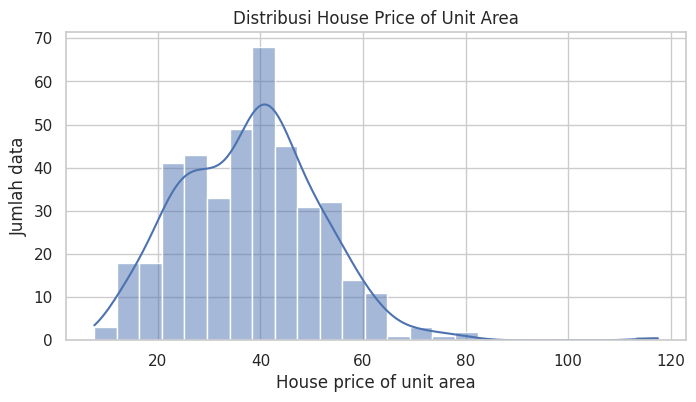

In [23]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=25, kde=True)
plt.title("Distribusi House Price of Unit Area")
plt.xlabel("House price of unit area")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Sebagian besar nilai target muncul pada rentang sekitar **20 sampai 50**.

> Apakah bentuk distribusinya mendekati lonceng sempurna atau condong ke salah satu sisi?

Jawaban: Distribusi tidak sepenuhnya berbentuk lonceng sempurna dan terlihat memiliki beberapa nilai tinggi di sisi kanan.

### Hitung korelasi fitur dengan target

Hitung korelasi setiap fitur terhadap target.

In [24]:
corr_with_target = df_clean.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
corr_with_target

X4 number of convenience stores           0.571
X5 latitude                               0.546
X6 longitude                              0.523
X2 house age                             -0.211
X3 distance to the nearest MRT station   -0.674
Name: Y house price of unit area, dtype: float64

> Berdasarkan output korelasi, fitur apa saja yang memiliki korelasi positif paling terlihat terhadap target?

Jawaban: `X4 number of convenience stores`, `X5 latitude`, dan `X6 longitude` memiliki korelasi positif paling terlihat terhadap target.

> Fitur apa yang memiliki korelasi negatif terhadap target?

Jawaban: `X3 distance to the nearest MRT station` dan `X2 house age` memiliki korelasi negatif terhadap target.

### Buat bar plot korelasi

Gunakan bar plot untuk melihat korelasi fitur dengan target secara visual.

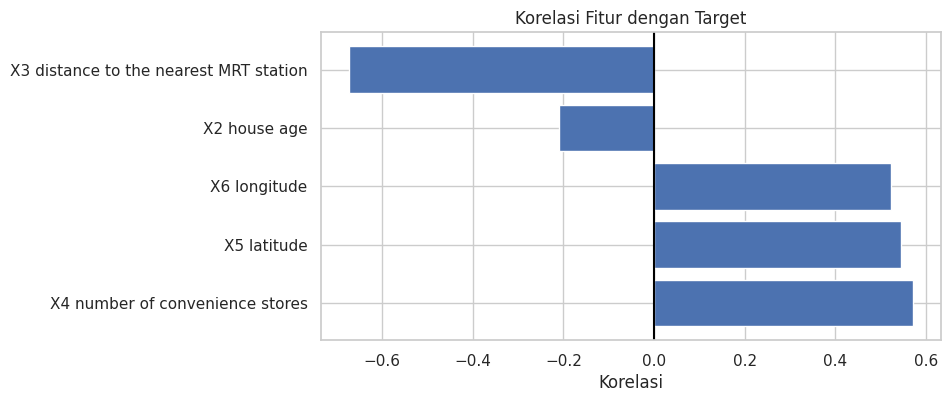

In [25]:
plt.figure(figsize=(8, 4))
plt.barh(corr_with_target.index, corr_with_target.values)
plt.axvline(0, color="black")
plt.title("Korelasi Fitur dengan Target")
plt.xlabel("Korelasi")
plt.show()

> Berdasarkan bar plot, fitur mana yang berada pada sisi korelasi positif dan sisi korelasi negatif?

Jawaban: Sisi positif berisi `X4 number of convenience stores`, `X5 latitude`, dan `X6 longitude`. Sisi negatif berisi `X2 house age` dan `X3 distance to the nearest MRT station`.

> Apa arti arah korelasi tersebut terhadap target?

Jawaban: Korelasi positif berarti nilai fitur cenderung naik bersama target, sedangkan korelasi negatif berarti nilai fitur cenderung naik ketika target menurun.

### Buat bar plot rata-rata target berdasarkan convenience stores

Gunakan bar plot untuk melihat rata-rata house price pada setiap jumlah convenience store.

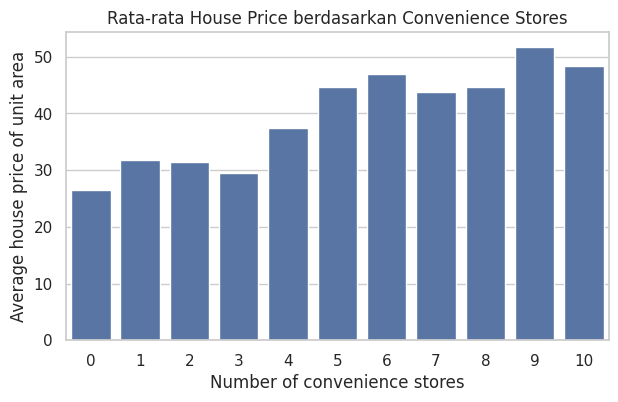

In [26]:
store_mean = df_clean.groupby("X4 number of convenience stores")[TARGET_COL].mean().reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(data=store_mean, x="X4 number of convenience stores", y=TARGET_COL)
plt.title("Rata-rata House Price berdasarkan Convenience Stores")
plt.xlabel("Number of convenience stores")
plt.ylabel("Average house price of unit area")
plt.show()

> Berdasarkan bar plot, bagaimana perubahan rata-rata target pada setiap jumlah convenience store?

Jawaban: Rata-rata target cenderung lebih tinggi ketika jumlah convenience store lebih banyak, meskipun tidak selalu naik sempurna di setiap nilai.

> Mengapa bar plot rata-rata lebih tepat daripada scatter plot untuk fitur ini?

Jawaban: Bar plot rata-rata lebih tepat karena jumlah convenience store memiliki nilai diskrit 0 sampai 10, sehingga lebih mudah dibaca sebagai perbandingan kelompok.

### Buat scatter plot jarak MRT dan target

Gunakan scatter plot dengan garis tren untuk melihat hubungan jarak MRT dengan target.

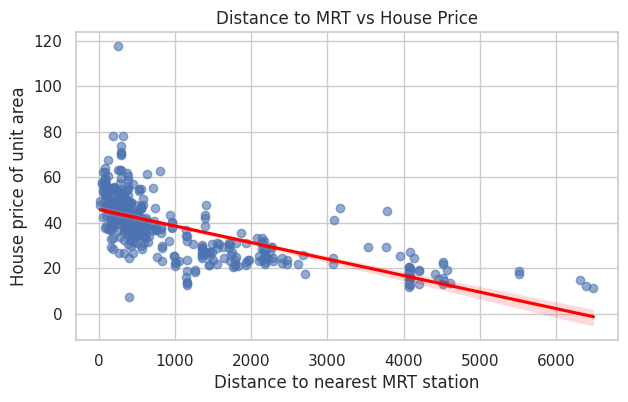

In [27]:
plt.figure(figsize=(7, 4))
sns.regplot(
    data=df_clean,
    x="X3 distance to the nearest MRT station",
    y=TARGET_COL,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Distance to MRT vs House Price")
plt.xlabel("Distance to nearest MRT station")
plt.ylabel("House price of unit area")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan jarak MRT dengan target?

Jawaban: Semakin jauh jarak ke MRT, harga rumah per unit area cenderung lebih rendah.

> Apakah garis tren menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis tren menunjukkan arah hubungan **negatif**.

## 6 - Feature dan Target

### Pisahkan fitur

Simpan semua kolom selain target ke variabel `X`.

In [28]:
X = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke variabel `y`.

In [29]:
y = df_clean[TARGET_COL]

### Tampilkan ukuran fitur

Cek ukuran `X` setelah fitur dipisahkan.

In [30]:
X.shape

(414, 5)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki **414 baris** dan **5 fitur**.

### Tampilkan ukuran target

Cek ukuran `y` setelah target dipisahkan.

In [31]:
y.shape

(414,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki **414 nilai target**.

> Apakah jumlah baris `X` dan `y` sudah sama?

Jawaban: Ya, jumlah baris `X` dan `y` sudah sama, yaitu **414**.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [32]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji yang digunakan adalah **20%**, sedangkan data latih adalah **80%** dari seluruh dataset.

### Bagi data train dan test

Bagi data menjadi data train dan test.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Cek jumlah data dan fitur pada `X_train`.

In [34]:
X_train.shape

(331, 5)

### Tampilkan ukuran X_test

Cek jumlah data dan fitur pada `X_test`.

In [35]:
X_test.shape

(83, 5)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki **331 baris**, sedangkan data test memiliki **83 baris**.

> Apakah jumlah fitur pada train dan test tetap sama?

Jawaban: Ya, jumlah fitur pada train dan test tetap sama, yaitu **5 fitur**.

## 8 - Feature Scaling

### Buat object scaler

Gunakan `StandardScaler` untuk menstandarkan fitur.

In [36]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler hanya pada data train, lalu transform data train.

In [37]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Transform data test menggunakan scaler yang sudah di-fit pada data train.

In [38]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [39]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [40]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan untuk prediksi?

Jawaban: Output `LinearRegression()` menunjukkan bahwa object model sudah berhasil dilatih dan siap digunakan untuk prediksi.

### Tampilkan intercept model

Tampilkan nilai intercept dari model.

In [41]:
model.intercept_

np.float64(38.39154078549814)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar **38.39**.

> Apa makna intercept setelah seluruh fitur di-scale?

Jawaban: Intercept adalah nilai dasar prediksi ketika seluruh fitur berada pada titik nol setelah scaling.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel sederhana.

In [42]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_table.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
2,X4 number of convenience stores,3.259
3,X5 latitude,2.943
4,X6 longitude,-0.357
0,X2 house age,-3.060
1,X3 distance to the nearest MRT station,-5.536


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar dan koefisien negatif terbesar?

Jawaban: Koefisien positif terbesar adalah `X4 number of convenience stores` sekitar **3.26**, sedangkan koefisien negatif terbesar adalah `X3 distance to the nearest MRT station` sekitar **-5.54**.

> Apa arti tanda positif dan negatif pada koefisien?

Jawaban: Koefisien positif berarti fitur cenderung menaikkan prediksi, sedangkan koefisien negatif berarti fitur cenderung menurunkan prediksi.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk memprediksi data train.

In [43]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk memprediksi data test.

In [44]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama dari data test.

In [45]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": y_test_pred[:5]
})
prediction_preview

,Actual,Predicted
0,45.100,47.742
1,42.300,41.955
2,52.200,44.540
3,37.300,41.337
4,22.800,30.285


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dan paling jauh dari nilai aktual?

Jawaban: Prediksi paling dekat terlihat pada baris ke-2, dengan aktual **42.30** dan prediksi **41.95**. Prediksi paling jauh terlihat pada baris ke-5, dengan aktual **22.80** dan prediksi **30.29**.

> Apa yang bisa disimpulkan dari selisih aktual dan prediksi?

Jawaban: Beberapa prediksi cukup dekat dengan nilai aktual, tetapi masih ada prediksi dengan selisih cukup besar.

### Hitung MAE train

Hitung rata-rata error absolut pada data train.

In [46]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

6.390228422313142

### Hitung MAE test

Hitung rata-rata error absolut pada data test.

In [47]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

5.350138374356212

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar **5.35**.

> Apa arti rata-rata error absolut tersebut?

Jawaban: Artinya, rata-rata prediksi model meleset sekitar **5.35** dari nilai aktual.

### Hitung RMSE train

Hitung RMSE pada data train.

In [48]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(9.242991911585309)

### Hitung RMSE test

Hitung RMSE pada data test.

In [49]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(7.387891796775459)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar **7.39**.

> Mengapa nilai RMSE dapat lebih besar daripada MAE?

Jawaban: RMSE dapat lebih besar daripada MAE karena RMSE memberi penalti lebih besar pada error yang besar.

### Hitung R2 train

Hitung R2 Score pada data train.

In [50]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.5457883393347674

### Hitung R2 test

Hitung R2 Score pada data test.

In [51]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.6746481382828176

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar **0.67**.

> Berapa persen variasi target pada data test yang dapat dijelaskan oleh model?

Jawaban: Model dapat menjelaskan sekitar **67%** variasi target pada data test.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 ke dalam satu tabel ringkas.

In [52]:
evaluation_table = pd.DataFrame({
    "Subset": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
})
evaluation_table

,Subset,MAE,RMSE,R2
0,Train,6.390,9.243,0.546
1,Test,5.350,7.388,0.675


> Berdasarkan tabel evaluasi, bandingkan MAE, RMSE, dan R2 pada data train dan data test.

Jawaban: MAE test lebih kecil daripada MAE train, RMSE test lebih kecil daripada RMSE train, dan R2 test lebih besar daripada R2 train.

> Berapa persen perbedaannya, dan apa makna perbandingan tersebut?

Jawaban: MAE test sekitar **16.28%** lebih kecil, RMSE test sekitar **20.07%** lebih kecil, dan R2 test sekitar **23.61%** lebih besar dibanding train. Pada split ini, performa test terlihat lebih baik daripada train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk melihat kedekatan nilai aktual dan prediksi pada data test.

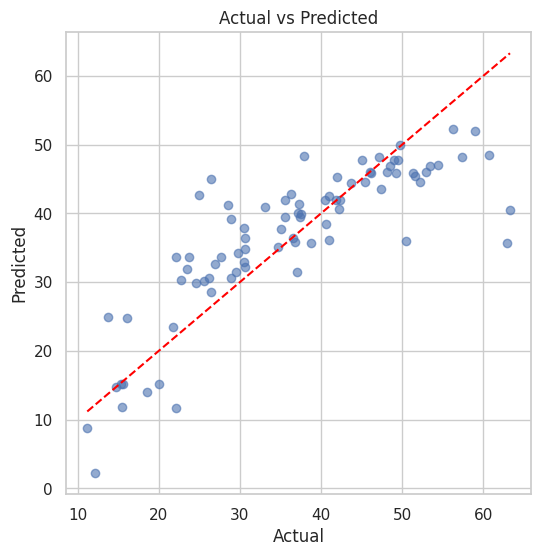

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## 11 - Kesimpulan

Dataset Real Estate Valuation digunakan untuk memprediksi `Y house price of unit area` berdasarkan fitur lokasi dan properti. Data tidak memiliki missing value dan tidak memiliki baris duplikat penuh. Setelah cleaning, dataset memiliki **414** baris dan **6** kolom karena kolom `X1 transaction date` dihapus.

Hasil EDA menunjukkan bahwa `X4 number of convenience stores`, `X5 latitude`, dan `X6 longitude` memiliki hubungan positif dengan target, sedangkan `X3 distance to the nearest MRT station` dan `X2 house age` cenderung memiliki hubungan negatif. Data dibagi menjadi **80%** data train dan **20%** data test, lalu fitur di-scale menggunakan `StandardScaler`.

Model Linear Regression menghasilkan MAE test sekitar **5.35**, RMSE test sekitar **7.39**, dan R2 test sekitar **0.67**. Berdasarkan metrik tersebut, model mampu menjelaskan sekitar **67%** variasi target pada data test dengan rata-rata error absolut sekitar **5.35**.